<a href="https://colab.research.google.com/github/nardien-amin/aml_project/blob/main/notebook59013e77e9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import os

In [8]:
os.environ['KAGGLE_USERNAME'] = "nardienamin"
os.environ['KAGGLE_KEY'] = "KGAT_44dabf2a04fb3daed3e1f41f572e1070"


!kaggle datasets download -d ashishjangra27/face-mask-12k-images-dataset


!unzip -q face-mask-12k-images-dataset.zip -d /content/dataset/
print("Download and extraction complete!")

Dataset URL: https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset
License(s): CC0-1.0
face-mask-12k-images-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/dataset/Face Mask Dataset/Test/WithMask/1163.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: Download and extraction complete!


In [9]:
base_path="/content/dataset/Face Mask Dataset"
data_directory=os.path.join(base_path,"Train")
validation_directory=os.path.join(base_path,"Validation")


In [22]:
train_transform=transforms.Compose(
    [transforms.Resize((256,256)),transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),transforms.Normalize(mean=[0.5,0.5,0.5],std=[0.25,0.25,0.25])
    ]
)

In [19]:
validation_transform=transforms.Compose(
    [transforms.Resize((256,256)),
    transforms.ToTensor(),transforms.Normalize(mean=[0.5,0.5,0.5],std=[0.25,0.25,0.25])
    ]
)

In [23]:
train_dataset=ImageFolder(root=data_directory,transform=train_transform)
validation_dataset=ImageFolder(root=validation_directory,transform=validation_transform)

In [24]:
batch_size=32
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
validation_loader=DataLoader(validation_dataset,batch_size=batch_size,shuffle=True)

In [14]:
class_names=train_dataset.classes
print(class_names)
len(train_dataset),len(validation_dataset)

['WithMask', 'WithoutMask']


(10000, 800)

# training model

In [28]:
import torchvision.models as models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)


for param in model.features.parameters():
    param.requires_grad = False


num_features = model.classifier[1].in_features
num_classes = len(class_names)

model.classifier[1] = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

In [26]:

print("Model device synchronization restored.")

Model device synchronization restored.


In [29]:
import torchvision.models as models
import torch.nn as nn
import torch
import time


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")


model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

for param in model.features.parameters():
    param.requires_grad = False

num_features = model.classifier[1].in_features
num_classes = len(class_names)
model.classifier[1] = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

num_epochs = 5
print("\n--- Starting Training ---")
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

end_time = time.time()
print(f"--- Training Complete in {(end_time - start_time)/60:.2f} minutes ---")

Training on device: cuda

--- Starting Training ---
Epoch 1/5 - Loss: 0.0921, Accuracy: 0.9638
Epoch 2/5 - Loss: 0.0646, Accuracy: 0.9761
Epoch 3/5 - Loss: 0.0447, Accuracy: 0.9844
Epoch 4/5 - Loss: 0.0360, Accuracy: 0.9862
Epoch 5/5 - Loss: 0.0324, Accuracy: 0.9872
--- Training Complete in 3.88 minutes ---


# Testing

In [30]:
import time

num_epochs = 5
print("\n--- Starting Training & Validation ---")
start_time = time.time()

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataset)
    train_acc = correct / total
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)


    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in validation_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(validation_dataset)
    val_acc = val_correct / val_total
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print(f"--- Training Complete in {(time.time() - start_time)/60:.2f} minutes ---")


--- Starting Training & Validation ---
Epoch 1/5 | Train Loss: 0.0338 Acc: 0.9865 | Val Loss: 0.0201 Acc: 0.9888
Epoch 2/5 | Train Loss: 0.0289 Acc: 0.9894 | Val Loss: 0.0252 Acc: 0.9900
Epoch 3/5 | Train Loss: 0.0341 Acc: 0.9882 | Val Loss: 0.0209 Acc: 0.9925
Epoch 4/5 | Train Loss: 0.0291 Acc: 0.9892 | Val Loss: 0.0219 Acc: 0.9925
Epoch 5/5 | Train Loss: 0.0249 Acc: 0.9919 | Val Loss: 0.0261 Acc: 0.9912
--- Training Complete in 4.05 minutes ---


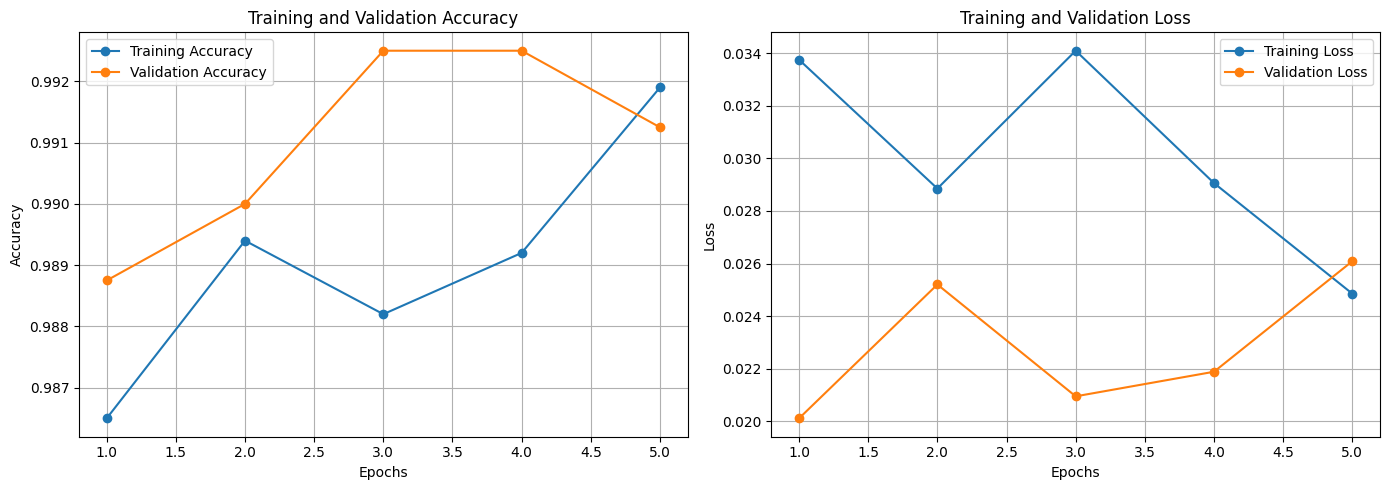

In [31]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_acc'], label='Training Accuracy', marker='o')
plt.plot(epochs, history['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_loss'], label='Training Loss', marker='o')
plt.plot(epochs, history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [32]:

save_path = "mobilenetv2_facemask.pth"
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to {save_path}")



Model successfully saved to mobilenetv2_facemask.pth


Running evaluation on validation dataset...

--- Classification Report ---
              precision    recall  f1-score   support

    WithMask       1.00      0.98      0.99       400
 WithoutMask       0.99      1.00      0.99       400

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800


--- Confusion Matrix ---


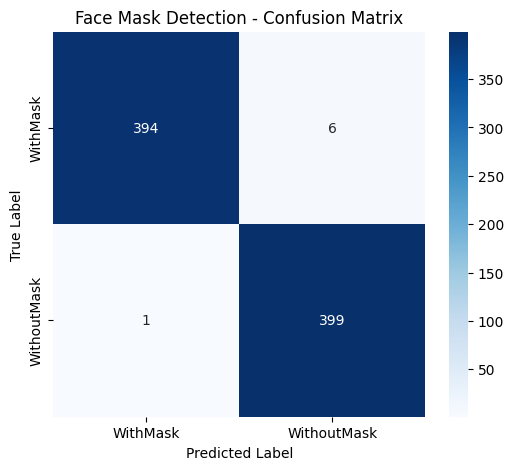

In [33]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

print("Running evaluation on validation dataset...")

with torch.no_grad():
    for inputs, labels in validation_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))


print("\n--- Confusion Matrix ---")
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Face Mask Detection - Confusion Matrix')
plt.show()